In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))  # adjust levels to reach your root

from experiments.init_models import HydraModel

In [2]:

from mrsqm import MrSQMClassifier, MrSQMTransformer
import numpy as np
import pandas as pd
from sklearn import metrics
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import timeit
import torch

from sklearn.linear_model import RidgeClassifierCV

from aeon.datasets import load_classification  
import warnings


In [3]:
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn")

In [4]:
ds = "Coffee"
X_train, y_train = load_classification(name=ds,split="train")
X_test, y_test = load_classification(name=ds,split="test")

print(ds)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

Coffee
(28, 1, 286) (28,)
(28, 1, 286) (28,)


In [5]:
clf = MrSQMClassifier().fit(X_train,y_train)

/Users/philiplynch/college/02_semester/ai4ts/assignments/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


In [6]:
y_pred = clf.predict(X_test)
print(metrics.accuracy_score(y_test, y_pred))

0.9642857142857143


In [7]:
tfm = MrSQMTransformer()

In [8]:
X_train_transform = tfm.fit_transform(X_train,y_train)
X_test_transform = tfm.transform(X_test)

In [9]:
# use ridgecv classifier
ridge = RidgeClassifierCV(alphas = np.logspace(-3, 3, 10)).fit(X_train_transform,y_train)
y_pred = ridge.predict(X_test_transform)
print(metrics.accuracy_score(y_test, y_pred))

0.9642857142857143


In [85]:
x.shape, w.shape

((286,), (286,))

In [82]:
# This example visualise the saliency map of the 1st sample (class '0') in the Coffee dataset 
clf = MrSQMClassifier(nsax=5,nsfa=0).fit(X_train,y_train)
x = X_train[1,0,:]
w = clf.get_saliency_map(x)[0,:]

/Users/philiplynch/college/02_semester/ai4ts/assignments/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


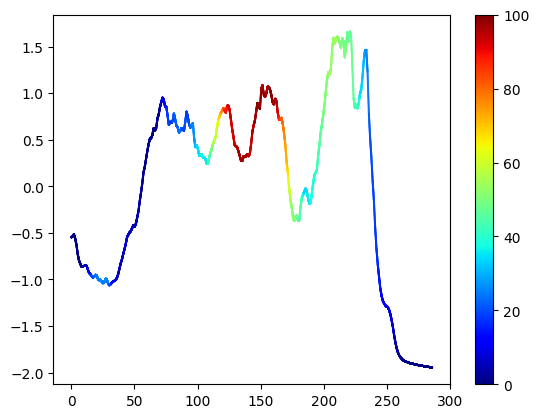

In [86]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt



def transform(X):
    ma,mi = np.max(X), np.min(X)
    X = (X - mi)/(ma-mi)
    return X*100
weight = abs(w)
weight = transform(weight)
ts = np.squeeze(x)
   
max_length1, max_length2 = ts.shape[0],10000 #
x1 = np.linspace(0,max_length1,num = max_length1)
x2 = np.linspace(0,max_length1,num = max_length2)
y1 = ts

f = interp1d(x1, y1) # interpolate time series
fcas = interp1d(x1, weight) # interpolate weight color
weight = fcas(x2) # convert vector of original weight vector to new weight vector

plt.scatter(x2,f(x2), c = weight, cmap = 'jet', marker='.', s= 1,vmin=0,vmax = 100)
# plt.xlabel('Explanation for index %d, dataset %s' %(idx, ds))
cbar = plt.colorbar(orientation = 'vertical')


plt.show()

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [88]:
scaler = StandardScaler()

classifier = LogisticRegression(
            solver='lbfgs',
            class_weight='balanced',
            max_iter=1000,
            multi_class='auto',
            C=1.0
        )

In [96]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((28, 1, 286), (28,), (28, 1, 286), (28,))

In [97]:
train_transform = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1))
test_transform = scaler.transform(X_test.reshape(X_test.shape[0], -1))

classifier.fit(train_transform, y_train)
y_pred = classifier.predict(test_transform)
print(metrics.accuracy_score(y_test, y_pred))

1.0


/Users/philiplynch/college/02_semester/ai4ts/assignments/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [113]:
w = classifier.coef_[0]
w.shape, train_transform.shape

((286,), (28, 286))

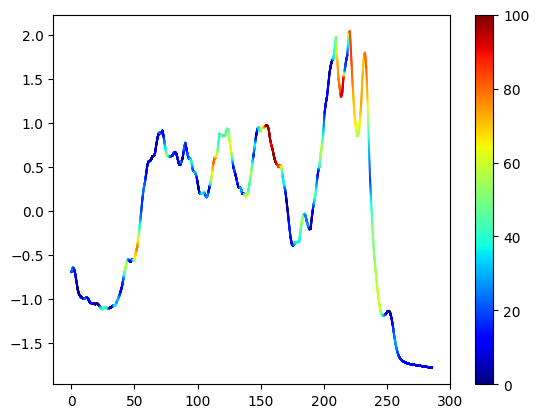

In [115]:
weight = abs(w)
weight = transform(weight)
sample_idx = 27
x = X_train[sample_idx,0,:]
ts = np.squeeze(x)
max_length1, max_length2 = ts.shape[0],10000 #
x1 = np.linspace(0,max_length1,num = max_length1)
x2 = np.linspace(0,max_length1,num = max_length2)
y1 = ts
f = interp1d(x1, y1) # interpolate time series
fcas = interp1d(x1, weight) # interpolate weight color
weight = fcas(x2) # convert vector of original weight vector to new weight vector 
plt.scatter(x2,f(x2), c = weight, cmap = 'jet', marker='.', s= 1,vmin=0,vmax = 100)
cbar = plt.colorbar(orientation = 'vertical')
plt.show()

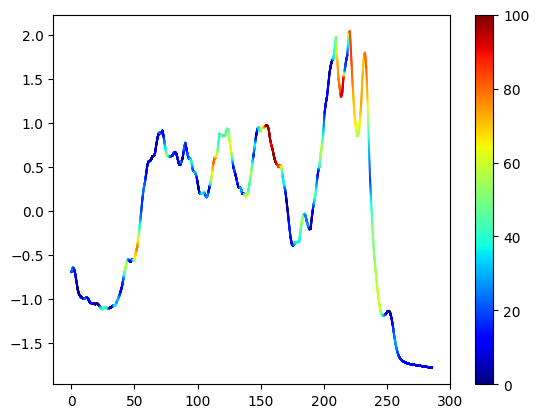

In [110]:
weight = abs(w)
weight = transform(weight)
sample_idx = 27
x = X_train[sample_idx,0,:]
ts = np.squeeze(x)
max_length1, max_length2 = ts.shape[0],10000 #
x1 = np.linspace(0,max_length1,num = max_length1)
x2 = np.linspace(0,max_length1,num = max_length2)
y1 = ts
f = interp1d(x1, y1) # interpolate time series
fcas = interp1d(x1, weight) # interpolate weight color
weight = fcas(x2) # convert vector of original weight vector to new weight vector 
plt.scatter(x2,f(x2), c = weight, cmap = 'jet', marker='.', s= 1,vmin=0,vmax = 100)
cbar = plt.colorbar(orientation = 'vertical')
plt.show()

In [73]:
w.shape, weight.shape, ts.shape, x2.shape,f(x2).shape

((286,), (10000,), (286,), (10000,), (10000,))

In [12]:
input_dim = X_train.shape[-1]

In [13]:
model = HydraModel(input_dim=input_dim, seed=42, device=torch.device("mps"))

[HydraModel] Using device: mps
[HydraModel] Using latency optimisation


In [14]:
predictions = model(X_train.reshape(-1, input_dim), y_train, X_test.reshape(-1, input_dim), y_test)

[HydraModel] Fitting model


In [15]:
input_dim

286

In [16]:
ridge_classifier = model.classifier
scaler = model.scaler

In [17]:
ridge_classifier.coef_

array([-3.40899279e-04,  6.34535829e-04, -1.24748113e-05, ...,
        1.31420726e-06, -4.40826635e-04, -8.41813973e-04], shape=(6144,))

In [18]:
class_index = 0
if len(ridge_classifier.coef_.shape) == 1 or ridge_classifier.coef_.shape[0] == 1:
    w_ridge = ridge_classifier.coef_[0]
else:
    w_ridge = ridge_classifier.coef_[class_index]
print(w_ridge)

-0.00034089927941833757


In [19]:
# 2. Adjust weights by the scaler's standard deviation
# (Avoid division by zero using the scaler's epsilon)
sigma = scaler.sigma.cpu().numpy()
w_adjusted = w_ridge / sigma

print(w_adjusted)


[-0.00598013 -0.00489438 -0.00324764 ... -0.00135331 -0.00123199
 -0.0006933 ]


In [20]:

# 3. Initialize the Saliency Map
seq_length = X_single.shape[-1]
saliency_map = np.zeros(seq_length, dtype=np.float32)

if self.divisor > 1:
    diff_X = torch.diff(X_single)

feature_offset = 0  # Keeps track of which feature column we are looking at


for dilation_index in range(self.num_dilations):
    d = self.dilations[dilation_index].item()
    p = self.paddings[dilation_index].item()

    for diff_index in range(self.divisor):
        _Z = F.conv1d(X_single if diff_index == 0 else diff_X,
                        self.W[dilation_index, diff_index],
                        dilation=d, padding=p).view(1, self.h, self.k, -1)

        # Get where the kernels activated
        max_values, max_indices = _Z.max(2)
        min_values, min_indices = _Z.min(2)

        # Both are shape: (1, h, seq_len)
        max_vals_np = max_values.squeeze(0).cpu().numpy()
        max_idx_np = max_indices.squeeze(0).cpu().numpy()

        min_vals_np = min_values.squeeze(0).cpu().numpy()
        min_idx_np = min_indices.squeeze(0).cpu().numpy()

        # Number of features per block (max or min)
        block_size = self.h * self.k

        # --- PROCESS MAX COUNTS ---
        # weights_max shape: (h, k)
        weights_max = w_adjusted[feature_offset: feature_offset + block_size].reshape(self.h, self.k)
        feature_offset += block_size

        # --- PROCESS MIN COUNTS ---
        weights_min = w_adjusted[feature_offset: feature_offset + block_size].reshape(self.h, self.k)
        feature_offset += block_size

        # Smear the weights back onto the original time series
        # For each group 'g_idx' and each timestep 't'
        for g_idx in range(self.h):
            for t in range(_Z.shape[-1]):
                # Which kernel won max?
                k_max = max_idx_np[g_idx, t]
                val_max = max_vals_np[g_idx, t]

                k_min = min_idx_np[g_idx, t]
                val_min = min_vals_np[g_idx, t]
                if val_max > 0:  # clamp(0) logic from scaler
                    weight_m = weights_max[g_idx, k_max]
                    # Smear across the 9 points of the receptive field
                    for kernel_step in range(9):
                        orig_t = t - p + (kernel_step * d)
                        if 0 <= orig_t < seq_length:
                            saliency_map[orig_t] += val_max * weight_m

                # Which kernel won min?
                k_min = min_idx_np[g_idx, t]
                # min is just counted (value = 1), not summed!
                weight_min = weights_min[g_idx, k_min]
                for kernel_step in range(9):
                    orig_t = t - p + (kernel_step * d)
                    if 0 <= orig_t < seq_length:
                        saliency_map[orig_t] += 1.0 * weight_min

NameError: name 'X_single' is not defined

In [21]:
ridge_classifier = model.classifier

print("Ridge classifier coefficients for class", class_index, ":", ridge_classifier.coef_)

Ridge classifier coefficients for class 0 : [-3.40899279e-04  6.34535829e-04 -1.24748113e-05 ...  1.31420726e-06
 -4.40826635e-04 -8.41813973e-04]


In [ ]:

if len(ridge_classifier.coef_.shape) == 1 or ridge_classifier.coef_.shape[0] == 1:
    w_ridge = ridge_classifier.coef_[0]
    print("Binary classification detected. Using the single coefficient vector.")
else:
    w_ridge = ridge_classifier.coef_[class_index]

Binary classification detected. Using the single coefficient vector.


In [32]:
y_test

array(['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0',
       '0', '0', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1'], dtype='<U1')

Saliency map generated! Shape: (286,)
Plotting saliency map for sample index 0 (true class 0)...


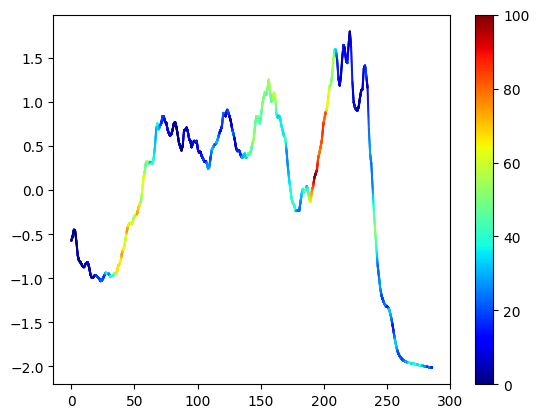

In [63]:
sample_index = 0  # Change this to visualize a different sample

x_sample = X_test[sample_index] 
class_index = y_test[sample_index]  # Get the true class index of the sample
# 3. Convert to tensor, ensure it is 3D (1, 1, seq_len), and move to the model's device
x_sample_torch = torch.tensor(x_sample, dtype=torch.float32).view(1, 1, -1)

# Check which device the Hydra weights are on, and send the sample there
device = model.transform.W.device
x_sample_torch = x_sample_torch.to(device)

# 4. Generate the saliency map!
# Note: You can change class_index to see what features the model looks for 
# to predict class 1 vs class 0.
raw_saliency = model.transform.get_saliency_map(
    x_sample_torch, 
    model.classifier, 
    model.scaler,
    class_index=class_index
)

print("Saliency map generated! Shape:", raw_saliency.shape)
print(f"Plotting saliency map for sample index {sample_index} (true class {class_index})...")
weight = abs(raw_saliency)
weight = transform(weight)
ts = np.squeeze(x_sample)
   
max_length1, max_length2 = ts.shape[0],10000 #
x1 = np.linspace(0,max_length1,num = max_length1)
x2 = np.linspace(0,max_length1,num = max_length2)
y1 = ts

f = interp1d(x1, y1) # interpolate time series
fcas = interp1d(x1, weight) # interpolate weight color
weight = fcas(x2) # convert vector of original weight vector to new weight vector

plt.scatter(x2,f(x2), c = weight, cmap = 'jet', marker='.', s= 1,vmin=0,vmax = 100)
# plt.xlabel('Explanation for index %d, dataset %s' %(idx, ds))
cbar = plt.colorbar(orientation = 'vertical')


plt.show()

(286,)

In [64]:
weight.shape

(10000,)

In [65]:
weight[np.where(weight >= 90)]

array([90.29644244, 90.68455131, 91.07266018, 91.46076904, 91.84887791,
       92.23698678, 92.62509565, 93.01320452, 93.40131338, 93.78942225,
       94.17753112, 94.56563999, 94.95374885, 95.34185772, 95.72996659,
       96.11807546, 96.27390265, 96.38268546, 96.49146826, 96.60025107,
       96.70903387, 96.81781668, 96.92659948, 97.03538229, 97.14416509,
       97.2529479 , 97.3617307 , 97.47051351, 97.57929631, 97.68807912,
       97.79686192, 97.90564473, 98.01442754, 98.12321034, 98.23199315,
       98.34077595, 98.44955876, 98.55834156, 98.66712437, 98.77590717,
       98.88468998, 98.99347278, 99.10225559, 99.21103839, 99.3198212 ,
       99.428604  , 99.53738681, 99.64616961, 99.75495242, 99.86373522,
       99.97251803, 99.7987367 , 99.52944074, 99.26014478, 98.99084882,
       98.72155286, 98.4522569 , 98.18296094, 97.91366497, 97.64436901,
       97.37507305, 97.10577709, 96.83648113, 96.56718517, 96.29788921,
       96.02859325, 95.75929729, 95.49000132, 95.22070536, 94.95

<Axes: ylabel='Frequency'>

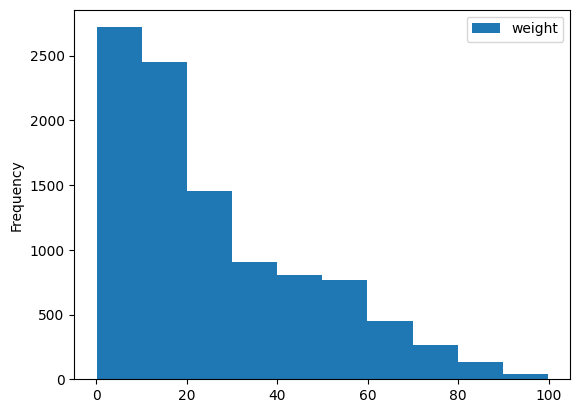

In [57]:
pd.DataFrame({'weight': weight}).plot(kind="hist")

Saliency map generated! Shape: (286,)
Plotting saliency map for sample index -12 (true class 1)...


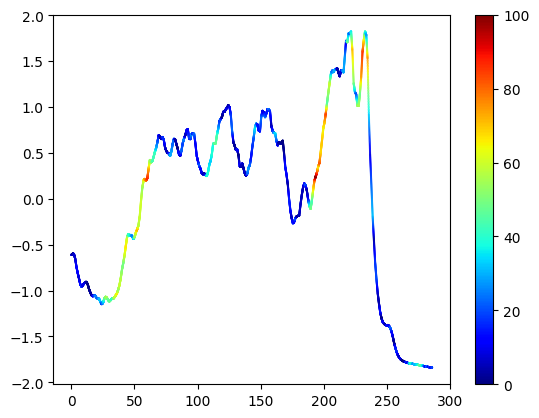

In [53]:
sample_index = -12 # Change this to visualize a different sample

x_sample = X_test[sample_index] 
class_index = y_test[sample_index]  # Get the true class index of the sample
# 3. Convert to tensor, ensure it is 3D (1, 1, seq_len), and move to the model's device
x_sample_torch = torch.tensor(x_sample, dtype=torch.float32).view(1, 1, -1)

# Check which device the Hydra weights are on, and send the sample there
device = model.transform.W.device
x_sample_torch = x_sample_torch.to(device)

# 4. Generate the saliency map!
# Note: You can change class_index to see what features the model looks for 
# to predict class 1 vs class 0.
raw_saliency = model.transform.get_saliency_map(
    x_sample_torch, 
    model.classifier, 
    model.scaler,
    class_index=class_index
)

print("Saliency map generated! Shape:", raw_saliency.shape)
print(f"Plotting saliency map for sample index {sample_index} (true class {class_index})...")
weight = abs(raw_saliency)
weight = transform(weight)
ts = np.squeeze(x_sample)
   
max_length1, max_length2 = ts.shape[0],10000 #
x1 = np.linspace(0,max_length1,num = max_length1)
x2 = np.linspace(0,max_length1,num = max_length2)
y1 = ts

f = interp1d(x1, y1) # interpolate time series
fcas = interp1d(x1, weight) # interpolate weight color
weight = fcas(x2) # convert vector of original weight vector to new weight vector

plt.scatter(x2,f(x2), c = weight, cmap = 'jet', marker='.', s= 1,vmin=0,vmax = 100)
# plt.xlabel('Explanation for index %d, dataset %s' %(idx, ds))
cbar = plt.colorbar(orientation = 'vertical')


plt.show()

In [ ]:
weight[weight > 80]

array([80.00913342, 80.06685521, 80.124577  , ..., 80.42273296,
       80.37449653, 80.15484861], shape=(1658,))